# Семинар 2. RAG, векторная база и память агента

На прошлой неделе агент ходил за фактами в живую Википедию и отвечал на 58 процентов свежих вопросов. Сегодня кладём знания рядом: режем корпус на куски, считаем эмбеддинги, ищем сначала на numpy, потом в Milvus, собираем RAG-ответ с источниками, разбираем провалы и даём агенту память. В конце превращаем поиск в инструмент агента. Дополнение для желающих: тот же конвейер на PDF.

Тезис курса прежний: **хороший агент на дешёвой модели обходится дешевле сильной модели в одиночку при том же качестве.** Сегодняшний вопрос к нему: сколько стоит верный ответ, когда знания лежат в индексе, и сколько в этой цене занимает контекст.

Восемь спринтов, десять дырок. Дырка это функция, у которой вместо тела стоит `...`, ни одна не длиннее десяти строк. Пояснения к дыркам, хронометраж и домашка в `README.md`.

## Что нужно

**Ключ** OpenRouter: локально файл `.env` рядом с ноутбуком, в Kaggle секрет `OPENROUTER_API_KEY` (Add-ons, Secrets, галочка подключения, перезапуск сессии). **Данные**: папка `data` рядом с ноутбуком, в Kaggle датасет `seminar02-data` и включённый Internet.

**Milvus** в Docker: в папке семинара лежит `docker-compose.yml`, команда `docker compose up -d` поднимает базу на `localhost:19530`. Первый запуск скачивает образ, около гигабайта, поэтому сделайте это до семинара. Если Docker поставить нельзя (Kaggle, Colab), в README есть раздел «Нет Docker».

В данных лежит готовый файл эмбеддингов корпуса `embeddings_512.npz`. С ним второй спринт занимает секунды. Без него те же векторы посчитаются через API за цент и минут двадцать: так было у нас при подготовке, и на общей сети аудитории будет не быстрее.

In [1]:
import os
os.environ["NO_PROXY"] = "pypi.org,files.pythonhosted.org"
os.environ["no_proxy"] = "pypi.org,files.pythonhosted.org"

In [2]:
%pip install -q requests pydantic python-dotenv pandas matplotlib numpy pymilvus pypdf

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Arthur\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
from pymilvus import MilvusClient

client = MilvusClient(uri="http://localhost:19530")
print(client.list_collections())


['lines', 'facts']


In [4]:
import os, re, sys, json, time, hashlib, threading
from pathlib import Path
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from pymilvus import MilvusClient

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
EMBED_URL = "https://openrouter.ai/api/v1/embeddings"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}", "X-Title": "agents-course-seminar02"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
EMBED_MODEL, DIM = "openai/text-embedding-3-small", 512
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = next((p for p in [Path("data"), Path("/kaggle/input/seminar02-data"), Path("/kaggle/input/seminar02-data/data")]
             if (p / "corpus_2026.jsonl").exists()), Path("data"))
Path("img").mkdir(exist_ok=True)


@dataclass
class Ledger:
    calls: list = field(default_factory=list)
    local: threading.local = field(default_factory=threading.local)

    def add(self, tag, model, usage, seconds=0.0):
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": usage.get("prompt_tokens", 0),
                           "completion": usage.get("completion_tokens", 0), "cost": cost, "seconds": round(seconds, 2)})
        self.local.spent = self.mine + cost
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    @property
    def mine(self):
        return getattr(self.local, "spent", 0.0)

    def table(self):
        frame = pd.DataFrame(self.calls, columns=["tag", "model", "prompt", "completion", "cost", "seconds"])
        return frame.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                                      completion=("completion", "sum"), cost=("cost", "sum")).round(5)


ledger = Ledger()


def post_with_retry(url, body, attempts=5):
    problem = "нет ответа"
    for attempt in range(attempts):
        try:
            r = requests.post(url, json=body, headers=HEADERS, timeout=120)
            if r.status_code == 200:
                return r.json()
            problem = f"HTTP {r.status_code}: {r.text[:200]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(problem)


def chat(messages, model, tools=None, tag="chat"):
    body = {"model": model, "messages": messages, "temperature": 0, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
    started = time.perf_counter()
    data = post_with_retry(CHAT_URL, body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]


def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

## Спринт 1. Корпус и нарезка

Корпус это 28 обзорных страниц Википедии про 2026 год, 830 тысяч символов. Вопросы те же, что в первой домашке: 124 штуки, на которых Sonnet без инструментов не отвечает. У каждого вопроса есть поле `evidence`, исходная строка с ответом, поэтому мы точно знаем, какой кусок верный, и сможем считать качество поиска без ручной разметки.

Страница устроена как список датированных событий: одна строка, одно событие. Отсюда два способа резать. Наивный: по 400 символов, не глядя на границы. По структуре: одна строка это один кусок, а заголовок раздела (месяц) едет с куском как метаданные.

Дырка: нарезка по строкам. Чекпоинт: число кусков в обеих нарезках и пример факта, который наивная нарезка разорвала пополам.

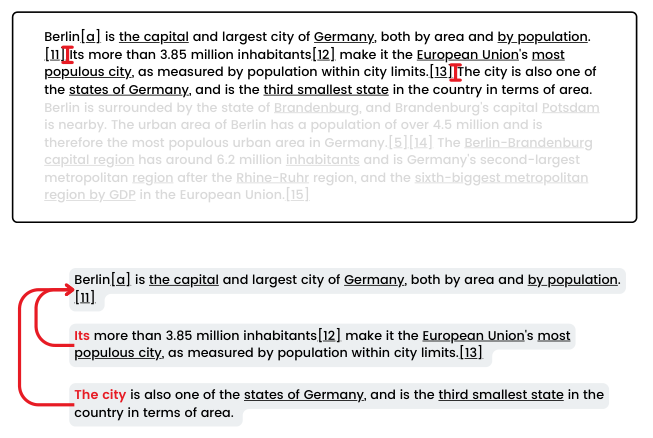

*Günther et al., 2024. Кусок без контекста: во втором и третьем предложении слова «Берлин» уже нет. Поэтому к тексту куска мы приписываем название страницы*

In [5]:
corpus, tasks = load_jsonl("corpus_2026.jsonl"), load_jsonl("fresh_2026.jsonl")
len(corpus), sum(len(p["text"]) for p in corpus), len(tasks), tasks[0]

(28,
 827482,
 124,
 {'id': 'fresh-0',
  'source': 'fresh',
  'question': 'On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics?',
  'answer': '15 March',
  'evidence': '15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 2022.',
  'page': '2026 in Ukraine',
  'url': 'https://en.wikipedia.org/wiki/2026_in_Ukraine',
  'agent_ok': False})

In [6]:
idx = corpus[0]["text"].find("\nJanuary")
print(idx)

print(repr(corpus[0]["text"][idx:idx+800]))

4131
'\nJanuary 1\nBulgaria adopts the euro, becoming the 21st member state of the eurozone.\nCyprus begins its role as President of the Council of the European Union.\n41 people are killed and 116 injured in a fire at a bar in Crans-Montana, Switzerland.\nJanuary 2 – Equatorial Guinea moves its capital from Malabo to Ciudad de la Paz.\nJanuary 3 – The United States launches several airstrikes on multiple locations across northern Venezuela, capturing Venezuelan president Nicolás Maduro and first lady Cilia Flores.\nJanuary 5 – Delcy Rodríguez is formally sworn in as the acting president of Venezuela after the capture of Nicolás Maduro.\nJanuary 6\nThe 2025 Jubilee ends.\nFighting between Syrian government forces and the Kurdish armed group Syrian Democratic Forces begins.\nJanuary 7 – The United States se'


In [7]:
def chunk_lines(page):
    chunks, section = [], ""
    months = "January|February|March|April|May|June|July|August|September|October|November|December"
    for line in (l.strip() for l in page["text"].split("\n") if l.strip()):
        m = re.match(rf"^({months}) \d{{1,2}}\b(\s*–\s*.+)?$", line)
        if m:
            section = line.split(" – ")[0]
            if not m.group(2):
                continue
        chunks.append({"page": page["page"], "section": section, "url": page["url"], "text": line})
    return chunks


In [8]:
def chunk_chars(page, size=400):
    text = " ".join(page["text"].split())
    return [{"page": page["page"], "section": "", "url": page["url"], "text": text[i:i + size]} for i in range(0, len(text), size)]

line_chunks = [c for p in corpus for c in chunk_lines(p)]
char_chunks = [c for p in corpus for c in chunk_chars(p)]
len(line_chunks), len(char_chunks), line_chunks[100]

(7835,
 2077,
 {'page': '2026',
  'section': 'April 8',
  'url': 'https://en.wikipedia.org/wiki/2026',
  'text': 'April 8 – Israel launches a series of airstrikes across Lebanon, targeting Hezbollah infrastructure. More than 300 people are killed and over 1,100 injured.'})

In [9]:
def torn(task):
    words = re.findall(r"\w+", task["evidence"].lower())
    head, tail = " ".join(words[:6]), " ".join(words[-6:])
    parts = [c["text"] for c in char_chunks if c["page"] == task["page"]
             and (head in " ".join(re.findall(r"\w+", c["text"].lower())) or tail in " ".join(re.findall(r"\w+", c["text"].lower())))]
    return parts if len(parts) == 2 else None

example = next(t for t in tasks if torn(t))
print("вопрос:", example["question"], "| ответ:", example["answer"])
for n, part in enumerate(torn(example), 1):
    print(f"кусок {n}: ...{part[-160:]}" if n == 1 else f"кусок {n}: {part[:160]}...")

вопрос: On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics? | ответ: 15 March
кусок 1: ...ic partnership agreement in the defense and energy sectors. 15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest 
кусок 2: over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 2022. 19 March – Forme...


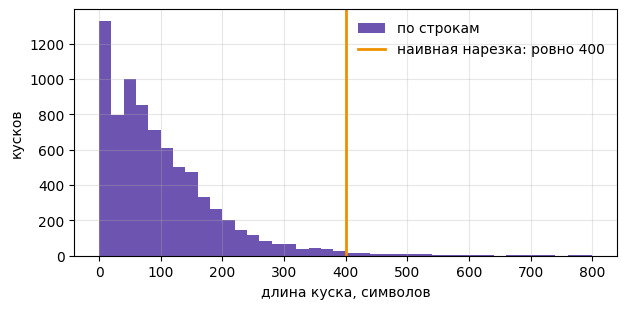

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist([len(c["text"]) for c in line_chunks], bins=40, range=(0, 800), color=COLORS["violet"], alpha=0.85, label="по строкам")
ax.axvline(400, color=COLORS["amber"], lw=2, label="наивная нарезка: ровно 400")
ax.set_xlabel("длина куска, символов"); ax.set_ylabel("кусков"); ax.legend(frameon=False); ax.grid(alpha=0.3);

## Спринт 2. Эмбеддинги и кэш

Эмбеддинг текста не меняется, пока не меняются текст и модель, поэтому считать его дважды незачем. Кэш устроен просто: ключ это хэш текста, значение это вектор. Сначала в кэш загружается готовый файл из данных, потом всё, чего там нет, досчитывается через API пачками по 64 текста.

Вектор берём укороченный, 512 измерений вместо 1536: это «матрёшка» из пятой лекции, параметр `dimensions` в запросе. Ответ API втрое легче, память втрое меньше, качество почти то же. Пачка в 256 текстов на полной размерности это восемь мегабайт JSON, и на медленной сети такой запрос просто не доходит.

Дырка: `embed_cached`. Чекпоинт: матрицы векторов для обеих нарезок и вопросов и строка в леджере с ценой.

In [11]:
EMB = {}

def load_cache():
    for path in [DATA / "embeddings_512.npz", Path("emb_cache.npz")]:
        if path.exists():
            z = np.load(path)
            EMB.update({str(k): v.astype(np.float32) for k, v in zip(z["keys"], z["vectors"])})
    return len(EMB)

def save_cache():
    np.savez_compressed("emb_cache.npz", keys=np.array(list(EMB)), vectors=np.stack(list(EMB.values())).astype(np.float16))

def embed_batch(texts):
    started = time.perf_counter()
    data = post_with_retry(EMBED_URL, {"model": EMBED_MODEL, "input": texts, "dimensions": DIM})
    ledger.add("embed", EMBED_MODEL, data.get("usage") or {}, time.perf_counter() - started)
    return [row["embedding"] for row in data["data"]]

def key_of(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

load_cache()

10494

In [12]:
def embed_cached(texts):
    todo = list({t for t in texts if key_of(t) not in EMB})
    for i in range(0, len(todo), 64):
        batch = todo[i:i + 64]
        for t, v in zip(batch, embed_batch(batch)):
            EMB[key_of(t)] = np.array(v, dtype=np.float32)
    return np.array([EMB[key_of(t)] for t in texts])

In [13]:
import os
os.environ["NO_PROXY"] = "openrouter.ai,localhost,127.0.0.1"
os.environ["no_proxy"] = os.environ["NO_PROXY"]

In [14]:
def emb_text(chunk):
    return f"{chunk['page']}: {chunk['text']}"

line_vecs = embed_cached([emb_text(c) for c in line_chunks])
char_vecs = embed_cached([c["text"] for c in char_chunks])
q_vecs = embed_cached([t["question"] for t in tasks])
save_cache()
line_vecs.shape, char_vecs.shape, q_vecs.shape

((7835, 512), (2077, 512), (124, 512))

In [15]:
probe = embed_cached(["Who won the 2026 FIFA World Cup?", "Which country became world champion in football in 2026?", "What was the weather in Tokyo yesterday?"])
save_cache()
(probe @ probe.T).round(2), ledger.table()

(array([[1.  , 0.81, 0.07],
        [0.81, 1.  , 0.05],
        [0.07, 0.05, 1.  ]], dtype=float32),
 Empty DataFrame
 Columns: [calls, prompt, completion, cost]
 Index: [])

## Спринт 3. Поиск на numpy и recall@k

Векторы нормализованы, значит косинусная близость это скалярное произведение, а близость вопроса ко всему корпусу это одно умножение матрицы на вектор. Для шести тысяч кусков этого хватает с запасом.

Качество поиска меряем отдельно от качества ответа. `recall@k` это доля вопросов, у которых верный кусок попал в первые k. Верным считаем кусок с той же страницы, в котором есть ответ и не меньше половины слов исходной строки: так наивная нарезка честно получает штраф за разорванные факты.

Дырка: `search_numpy`. Чекпоинт: кривая recall@k для двух нарезок.

In [16]:
def search_numpy(query_vec, vectors, k=5):
    scores = vectors @ query_vec
    top = np.argsort(-scores)[:k]
    return [(i, float(scores[i])) for i in top]


In [17]:
NUMBERS = {word: str(n) for n, word in enumerate("zero one two three four five six seven eight nine ten eleven twelve".split())}

def norm(text):
    words = re.sub(r"\b(a|an|the)\b|[^\w\s]", " ", str(text).lower()).split()
    return " ".join(NUMBERS.get(w, w) for w in words)

def is_gold(chunk, task):
    if chunk["page"] != task["page"]:
        return False
    text, words = norm(chunk["text"]), norm(task["evidence"]).split()
    return norm(task["answer"]) in text and sum(w in text for w in words) >= 0.5 * len(words)

def recall_curve(chunks, vectors, ks=(1, 3, 5, 10, 20)):
    ranked = [[i for i, _ in search_numpy(q, vectors, max(ks))] for q in q_vecs]
    return {k: float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(ranked, tasks)])) for k in ks}

for i, score in search_numpy(q_vecs[0], line_vecs, 3):
    print(round(score, 3), "|", line_chunks[i]["page"], "|", line_chunks[i]["text"][:110])
tasks[0]["question"], tasks[0]["answer"]

0.821 | 2026 in Ukraine | 15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest over Russi
0.803 | 2026 in Ukraine | Ukraine boycotts the opening ceremony of the 2026 Winter Paralympics in Italy in protest over Russian athletes
0.669 | 2026 in Ukraine | 6–22 February –  Ukraine at the 2026 Winter Olympics


('On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics?',
 '15 March')

,по строкам,по 400 символов
1,0.88,0.52
3,0.97,0.74
5,0.98,0.81
10,0.98,0.85
20,0.99,0.91


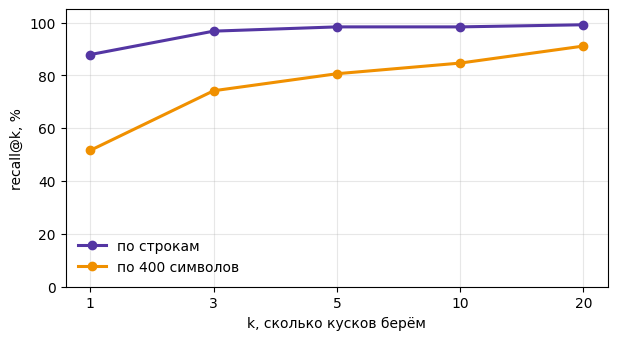

In [18]:
curves = {"по строкам": recall_curve(line_chunks, line_vecs), "по 400 символов": recall_curve(char_chunks, char_vecs)}
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, curve), color in zip(curves.items(), [COLORS["violet"], COLORS["amber"]]):
    ax.plot([str(k) for k in curve], [v * 100 for v in curve.values()], marker="o", lw=2.2, color=color, label=name)
ax.set_xlabel("k, сколько кусков берём"); ax.set_ylabel("recall@k, %"); ax.set_ylim(0, 105); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/recall.png", dpi=150, bbox_inches="tight")
pd.DataFrame(curves).round(2)

## Спринт 4. Milvus

Перебор на numpy честный и быстрый, но это только поиск. База добавляет то, что нужно продукту: хранение на диске, метаданные рядом с вектором, фильтры, добавление и удаление без пересборки, индекс для миллионов векторов и доступ по сети для нескольких сервисов сразу.

Milvus поднимаем так же, как его поднимают в жизни: контейнером. В папке семинара лежит `docker-compose.yml`, в нём один сервис, сам Milvus в режиме standalone со встроенным etcd и локальным хранилищем.

```
docker compose up -d        поднять, база слушает localhost:19530
docker compose ps           статус должен стать healthy
docker compose logs -f      посмотреть, что происходит внутри
docker compose down         остановить, данные останутся в томе
docker compose down -v      остановить и стереть данные
```

В боевой установке etcd и объектное хранилище (MinIO или S3) живут отдельными сервисами, а сам Milvus раскладывается на несколько узлов. Код клиента от этого не меняется: меняется только адрес в `MILVUS_URI`.

Рядом с вектором храним всё, что понадобится показать человеку и подложить модели: текст куска, страницу, раздел, ссылку. Поля, которых нет в схеме, Milvus складывает как динамические, и по ним можно фильтровать. После вставки зовём `flush`: он запечатывает сегмент, по нему строится индекс, а `row_count` в статистике становится точным.

Две дырки: загрузка кусков в коллекцию и поиск с фильтром. Чекпоинт: выдача Milvus почти полностью совпадает с перебором, фильтр по странице работает, и два замера скорости: на нашем корпусе и на корпусе, раздутом до двухсот тысяч векторов.

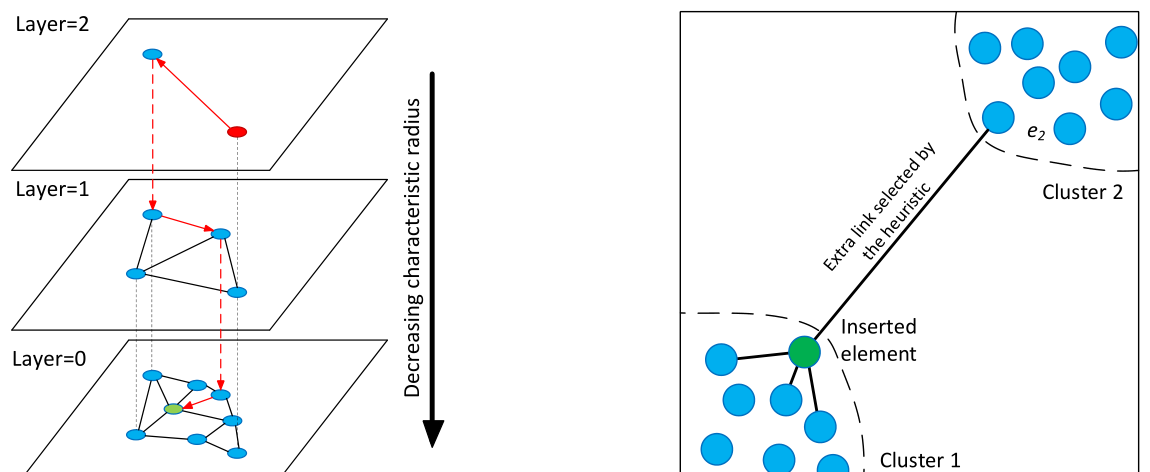

*Malkov, Yashunin, 2016. HNSW: слои графа как автострады и улицы. Milvus строит такой индекс сам, поэтому поиск приближённый: быстрый, но совпадает с перебором не на все сто процентов*

In [19]:
MILVUS_URI = os.getenv("MILVUS_URI", "http://localhost:19530")
client = MilvusClient(uri=MILVUS_URI, token=os.getenv("MILVUS_TOKEN", ""))
if os.getenv("MILVUS_DB"):
    if os.environ["MILVUS_DB"] not in client.list_databases():
        client.create_database(os.environ["MILVUS_DB"])
    client.use_database(os.environ["MILVUS_DB"])
client.get_server_version(), client.list_collections()

('2.6.24', ['lines', 'facts'])

In [20]:
def index_to_milvus(name, chunks, vectors):
    if client.has_collection(name):
        client.drop_collection(name)
    client.create_collection(name, dimension=vectors.shape[1], metric_type="COSINE")
    for i in range(0, len(chunks), 5000):
        batch = [{"id": i + j, "vector": v, **chunks[i + j]} for j, v in enumerate(vectors[i:i + 5000].tolist())]
        client.insert(name, batch)
    client.flush(name)
    return client.get_collection_stats(name)


In [21]:
def search_milvus(name, query, k=5, flt=""):
    vec = embed_cached([query])[0]
    hits = client.search(name, data=[vec.tolist()], limit=k, filter=flt,
                          output_fields=["page", "section", "url", "text"])[0]
    return [{"id": h["id"], "score": h["distance"], **h["entity"]} for h in hits]

In [22]:
index_to_milvus("lines", line_chunks, line_vecs), client.describe_index("lines", "vector")

({'row_count': 7835},
 {'index_type': 'AUTOINDEX',
  'metric_type': 'COSINE',
  'field_name': 'vector',
  'index_name': 'vector',
  'total_rows': 7835,
  'indexed_rows': 0,
  'pending_index_rows': 7835,
  'state': 'InProgress'})

In [23]:
pd.DataFrame(search_milvus("lines", tasks[0]["question"], 3))[["score", "page", "section", "text"]]

,score,page,section,text
0,0.821296,2026 in Ukraine,,15 March – Ukraine boycotts the closing ceremo...
1,0.803359,2026 in Ukraine,,Ukraine boycotts the opening ceremony of the 2...
2,0.669116,2026 in Ukraine,,6–22 February – Ukraine at the 2026 Winter Ol...


In [24]:
from_numpy = [[i for i, _ in search_numpy(q, line_vecs, 5)] for q in q_vecs]
from_milvus = [[h["id"] for h in hits] for hits in client.search("lines", data=q_vecs.tolist(), limit=5)]
overlap = float(np.mean([len(set(a) & set(b)) / 5 for a, b in zip(from_numpy, from_milvus)]))
round(overlap, 3), sum(a == b for a, b in zip(from_numpy, from_milvus)), len(q_vecs)

(0.935, 97, 124)

In [25]:
pd.DataFrame(search_milvus("lines", "earthquake magnitude", 5, 'page == "2026 in Japan"'))[["score", "page", "section", "text"]]

,score,page,section,text
0,0.460323,2026 in Japan,April 20,April 20 – A magnitude 7.7 earthquake hits off...
1,0.457807,2026 in Japan,May 15,May 15 – A magnitude 6.3 earthquake strikes of...
2,0.455007,2026 in Japan,May 16,A magnitude 5.9 earthquake strikes southern Am...
3,0.435164,2026 in Japan,March 31,A magnitude 5.0 earthquake hits southern Tochi...
4,0.428810,2026 in Japan,April 27,April 27 – A magnitude 6.1 earthquake strikes ...


{'numpy, перебор': 1.52,
 'Milvus, запрос на вызов': 3.68,
 'Milvus, сто запросов пачкой': 0.18}

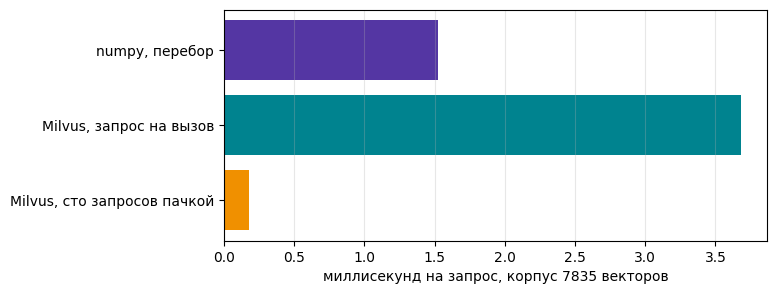

In [26]:
def per_query_ms(fn, n=100):
    started = time.perf_counter()
    fn()
    return (time.perf_counter() - started) * 1000 / n

queries = q_vecs[:100]
speed = {"numpy, перебор": per_query_ms(lambda: [search_numpy(q, line_vecs, 5) for q in queries]),
         "Milvus, запрос на вызов": per_query_ms(lambda: [client.search("lines", data=[q.tolist()], limit=5) for q in queries]),
         "Milvus, сто запросов пачкой": per_query_ms(lambda: client.search("lines", data=queries.tolist(), limit=5))}
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(speed), list(speed.values()), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]])
ax.invert_yaxis(); ax.set_xlabel(f"миллисекунд на запрос, корпус {len(line_vecs)} векторов"); ax.grid(alpha=0.3, axis="x")
{name: round(ms, 2) for name, ms in speed.items()}

,"numpy, перебор","Milvus, запрос на вызов","Milvus, пачкой"
векторов,,,
7835,2.79,4.50,0.26
50000,15.89,6.14,1.04
200000,70.23,8.09,1.33


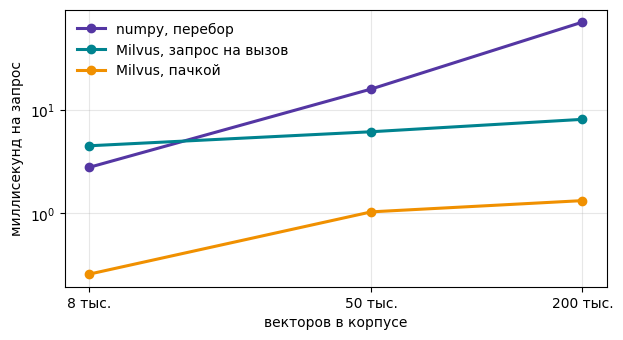

In [27]:
def inflate(vectors, n, noise=0.35, seed=0):
    rng = np.random.default_rng(seed)
    extra = vectors[rng.integers(0, len(vectors), n - len(vectors))]
    extra = extra + noise * rng.standard_normal(extra.shape, dtype=np.float32) / np.sqrt(vectors.shape[1])
    return np.vstack([vectors, extra / np.linalg.norm(extra, axis=1, keepdims=True)])

def wait_index(name, seconds=180):
    for _ in range(seconds):
        info = client.describe_index(name, "vector")
        if info.get("state") == "Finished" and info.get("pending_index_rows", 0) == 0:
            return True
        time.sleep(1)
    return False

scale_rows = []
for n in (len(line_vecs), 50_000, 200_000):
    big = inflate(line_vecs, n)
    if client.has_collection("scale"):
        client.drop_collection("scale")
    client.create_collection("scale", dimension=big.shape[1], metric_type="COSINE")
    for i in range(0, n, 5000):
        client.insert("scale", [{"id": i + j, "vector": v} for j, v in enumerate(big[i:i + 5000].tolist())])
    client.flush("scale")
    wait_index("scale")
    client.search("scale", data=[q_vecs[0].tolist()], limit=5)
    probe = q_vecs[:50]
    scale_rows.append({"векторов": n,
                       "numpy, перебор": per_query_ms(lambda: [search_numpy(q, big, 5) for q in probe], 50),
                       "Milvus, запрос на вызов": per_query_ms(lambda: [client.search("scale", data=[q.tolist()], limit=5) for q in probe], 50),
                       "Milvus, пачкой": per_query_ms(lambda: client.search("scale", data=probe.tolist(), limit=5), 50)})
client.drop_collection("scale")
scale = pd.DataFrame(scale_rows).set_index("векторов")
ax = scale.plot(figsize=(7, 3.6), marker="o", lw=2.2, logx=True, logy=True, color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]])
ax.set_xticks(list(scale.index)); ax.set_xticklabels([f"{n / 1000:.0f} тыс." for n in scale.index]); ax.minorticks_off()
ax.set_ylabel("миллисекунд на запрос"); ax.set_xlabel("векторов в корпусе"); ax.legend(frameon=False); ax.grid(alpha=0.3)
ax.figure.savefig("img/scale.png", dpi=150, bbox_inches="tight")
scale.round(2)

## Спринт 5. RAG-ответ и деньги

Найденные куски кладём в контекст с номерами и просим модель отвечать только по ним, ссылаться на номер источника и честно писать `NOT_FOUND`, если ответа в источниках нет. Правота проверяется как на первом семинаре: нормализованный эталон должен содержаться в ответе.

Дырка: `rag_answer`. После неё два замера на сорока вопросах. Первый: пять конфигураций, с RAG и без, на трёх ярусах моделей, и наша картинка «деньги против качества». Второй: сколько кусков класть в контекст. Recall с ростом k выходит на плато, а счёт за контекст растёт линейно, поэтому k выбирают по кривой, а не на глаз.

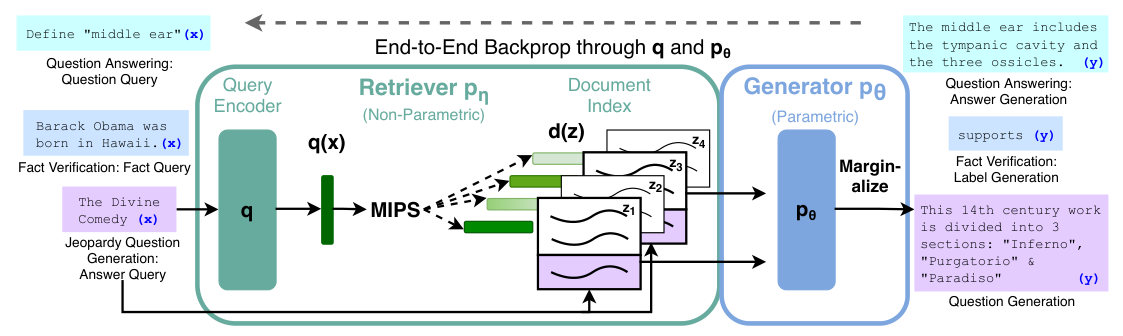

*Lewis et al., 2020. Оригинальная схема RAG: поиск подкладывает куски генератору. У нас то же самое, только через промпт и без обучения*

In [28]:
RAG_SYSTEM = ("Answer the question using only the numbered sources. Cite the source number like [2]. "
              "If the sources do not contain the answer, reply exactly NOT_FOUND. The last line must be FINAL: <short answer>.")
PLAIN_SYSTEM = "Answer the question. If you do not know, reply NOT_FOUND. The last line must be FINAL: <short answer>."

In [29]:
def rag_answer(question, model, k=5, name="lines"):
    before = ledger.mine
    hits = search_milvus(name, question, k)
    sources = "\n".join(f"[{i+1}] {h['text']}" for i, h in enumerate(hits))
    user = f"Sources:\n{sources}\n\nQuestion: {question}"
    msg = chat([{"role": "system", "content": RAG_SYSTEM}, {"role": "user", "content": user}], model, tag="rag")
    return {"answer": msg.get("content") or "", "hits": hits, "cost": ledger.mine - before}


In [30]:
client.list_collections()
client.get_collection_stats("lines")

{'row_count': 7835}

In [31]:
def plain_answer(question, model):
    before = ledger.mine
    msg = chat([{"role": "system", "content": PLAIN_SYSTEM}, {"role": "user", "content": question}], model, tag="plain")
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before}

def final_answer(text):
    m = re.findall(r"FINAL:\s*(.+)", text or "")
    return m[-1].strip() if m else (text or "").strip()

def is_correct(task, answer):
    return f" {norm(task['answer'])} " in f" {norm(final_answer(answer))} "

def evaluate(fn, sample, config, model, workers=8):
    def one(task):
        try:
            out = fn(task["question"], model)
        except Exception as e:
            out = {"answer": f"ошибка: {e}", "hits": [], "cost": 0.0}
        return {"config": config, "model": model.split("/")[-1], "id": task["id"], "correct": is_correct(task, out["answer"]),
                "found": any(is_gold(h, task) for h in out["hits"]), "refused": "NOT_FOUND" in out["answer"],
                "cost": out["cost"], "answer": final_answer(out["answer"])[:60], "gold": task["answer"]}
    with ThreadPoolExecutor(workers) as pool:
        return pd.DataFrame(list(pool.map(one, sample)))

def report(results):
    g = results.groupby(["config", "model"], sort=False)
    table = g.agg(n=("correct", "size"), accuracy=("correct", "mean"), cost_per_task=("cost", "mean")).reset_index()
    table["cost_per_correct"] = table["cost_per_task"] / table["accuracy"].replace(0, float("nan"))
    return table.round(5)

def money_chart(table, path, baseline=None):
    fig, ax = plt.subplots(figsize=(8, 4.6))
    if baseline:
        ax.axhline(baseline[1] * 100, color=COLORS["grey"], ls="--", lw=1.2)
        ax.annotate(baseline[0], (0.01, baseline[1] * 100 + 1.5), xycoords=("axes fraction", "data"), fontsize=8, color=COLORS["grey"])
    for _, r in table.iterrows():
        color = COLORS["amber"] if "sonnet" in r["model"] else COLORS["teal"] if "haiku" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100), fontsize=8, xytext=(7, 3), textcoords="offset points")
    ax.set_xscale("log"); ax.set_xlabel("цена вопроса, центы (логарифмическая шкала)"); ax.set_ylabel("доля верных, %"); ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

out = rag_answer(tasks[0]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[0]["answer"], "| цена, центов:", round(out["cost"] * 100, 4))

Ukraine boycotted the closing ceremony of the 2026 Winter Paralympics on 15 March [1]. 

FINAL: 15 March. | эталон: 15 March | цена, центов: 0.0054


In [32]:
sample = tasks[:40]
results = pd.concat([
    evaluate(plain_answer, sample, "без RAG", MODELS["cheap"]),
    evaluate(plain_answer, sample, "без RAG", MODELS["strong"]),
    evaluate(rag_answer, sample, "RAG, k=5", MODELS["cheap"]),
    evaluate(rag_answer, sample, "RAG, k=5", MODELS["mid"]),
    evaluate(rag_answer, sample, "RAG, k=5", MODELS["strong"]),
], ignore_index=True)
table = report(results)
table

,config,model,n,accuracy,cost_per_task,cost_per_correct
0,без RAG,gpt-4o-mini,40,0.000,0.00001,NaN
1,без RAG,claude-sonnet-4.6,40,0.025,0.00110,0.04400
2,"RAG, k=5",gpt-4o-mini,40,0.650,0.00005,0.00008
3,"RAG, k=5",claude-haiku-4.5,40,0.900,0.00058,0.00065
4,"RAG, k=5",claude-sonnet-4.6,40,0.875,0.00167,0.00191


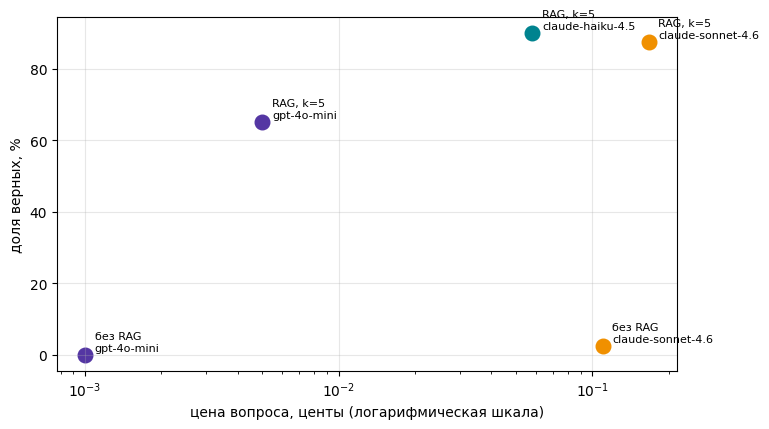

In [33]:
money_chart(table, "img/money_rag.png");

,config,model,n,accuracy,cost_per_task,cost_per_correct
0,k=1,gpt-4o-mini,40,0.625,0.00003,0.00005
1,k=3,gpt-4o-mini,40,0.650,0.00004,0.00006
2,k=5,gpt-4o-mini,40,0.625,0.00005,0.00008
3,k=10,gpt-4o-mini,40,0.675,0.00007,0.00010


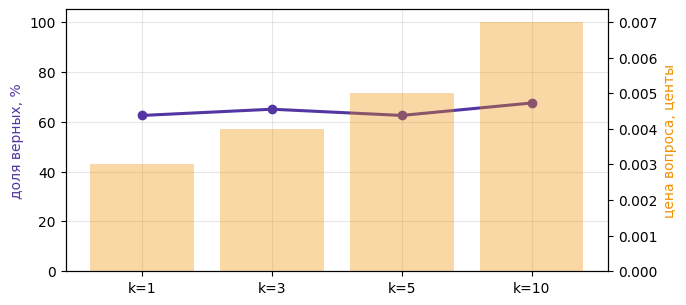

In [34]:
sweep = pd.concat([evaluate(lambda q, m, k=k: rag_answer(q, m, k), sample, f"k={k}", MODELS["cheap"]) for k in (1, 3, 5, 10)], ignore_index=True)
sweep_table = report(sweep)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(sweep_table["config"], sweep_table["accuracy"] * 100, marker="o", lw=2.2, color=COLORS["violet"]); ax.set_ylabel("доля верных, %", color=COLORS["violet"])
ax2 = ax.twinx(); ax2.bar(sweep_table["config"], sweep_table["cost_per_task"] * 100, alpha=0.35, color=COLORS["amber"]); ax2.set_ylabel("цена вопроса, центы", color=COLORS["amber"])
ax.set_ylim(0, 105); ax.grid(alpha=0.3)
sweep_table

## Спринт 6. Разбор провалов

У RAG две половины, и ломаются они по-разному. Поиск мог не найти нужный кусок. А мог найти, но модель ответила неверно или отказалась. Чинятся эти случаи в разных местах, поэтому первым делом раскладываем ошибки на две кучки.

Дальше три приёма. Гибрид: вектор ловит смысл, поиск по словам ловит точные имена и числа, слияние рангов RRF берёт лучшее от обоих. Проверим его на обеих нарезках: и там, где вектору тяжело, и там, где он уже хорош. Отказ: десять вопросов, ответа на которые в корпусе нет, и подсчёт, сколько раз система честно сказала `NOT_FOUND`. Порог близости: у неотвечаемых вопросов лучший кусок заметно дальше, и это дешёвый сигнал для отказа ещё до вызова модели.

Дырка: `rrf`. Чекпоинт: две кучки ошибок, recall до и после гибрида, гистограмма близостей.

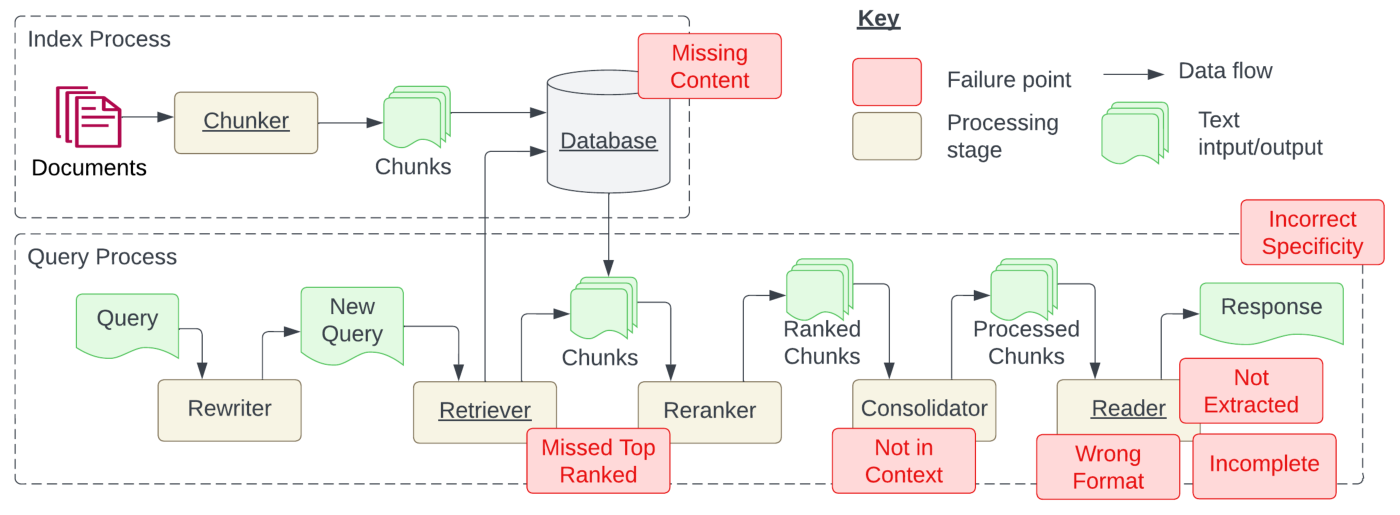

*Barnett et al., 2024. Семь точек отказа RAG из боевых систем: половина до генерации, половина в ней. Мерить надо обе*

In [35]:
def diagnose(results):
    wrong = results[~results["correct"] & results["config"].str.startswith("RAG")]
    return wrong.groupby("model").agg(не_нашли=("found", lambda s: int((~s).sum())), нашли_но_ответ_неверный=("found", "sum"))

diagnose(results)

,не_нашли,нашли_но_ответ_неверный
model,,
claude-haiku-4.5,3,1
claude-sonnet-4.6,3,2
gpt-4o-mini,3,11


In [36]:
results[~results["correct"] & (results["config"] == "RAG, k=5")][["model", "gold", "answer", "found"]]

,model,gold,answer,found
82,gpt-4o-mini,Miguel Díaz-Canel,NOT_FOUND.,False
83,gpt-4o-mini,a strategic partnership agreement,NOT_FOUND.,True
85,gpt-4o-mini,two people,2,True
87,gpt-4o-mini,Pavel Durov,NOT_FOUND.,True
90,gpt-4o-mini,Helter Skelter,NOT_FOUND,True
101,gpt-4o-mini,Clara and the Below,NOT_FOUND.,False
103,gpt-4o-mini,a drought,NOT_FOUND.,False
108,gpt-4o-mini,43,NOT_FOUND.,True
111,gpt-4o-mini,Richard Lewer,NOT_FOUND.,True
112,gpt-4o-mini,Marilyn Gladu,NOT_FOUND.,True


In [37]:
def tokens(text):
    return re.findall(r"\w+", text.lower())

def build_keyword_index(texts):
    docs = [set(tokens(text)) for text in texts]
    df = {}
    for d in docs:
        for w in d:
            df[w] = df.get(w, 0) + 1
    return docs, {w: np.log(len(docs) / n) for w, n in df.items()}

def keyword_search(query, docs, idf, k=20):
    q = set(tokens(query))
    scores = np.array([sum(idf.get(w, 0.0) for w in q & d) for d in docs])
    return [int(i) for i in np.argsort(-scores)[:k]]

In [38]:
def rrf(rankings, k=5, K=60):
    scores = {}
    for ranking in rankings:
        for rank, idx in enumerate(ranking, start=1):
            scores[idx] = scores.get(idx, 0.0) + 1.0 / (K + rank)
    return [i for i, _ in sorted(scores.items(), key=lambda x: -x[1])[:k]]


,нарезка,поиск,recall@1,recall@5
0,по 400 символов,только вектор,0.52,0.81
1,по 400 символов,только слова,0.76,0.90
2,по 400 символов,гибрид RRF,0.73,0.90
3,по строкам,только вектор,0.88,0.98
4,по строкам,только слова,0.90,0.98
5,по строкам,гибрид RRF,0.90,0.99


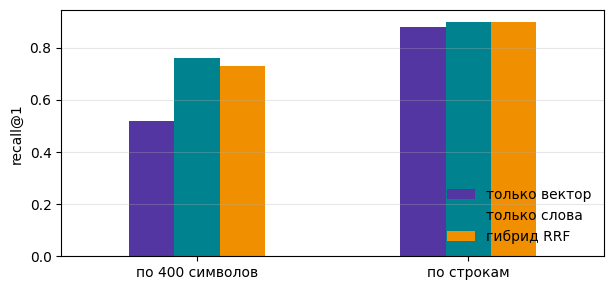

In [39]:
def recall_of(rankings, chunks, k=5):
    return float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(rankings, tasks)]))

rows = []
for cut, chunks, vectors, texts in [("по 400 символов", char_chunks, char_vecs, [c["text"] for c in char_chunks]),
                                    ("по строкам", line_chunks, line_vecs, [emb_text(c) for c in line_chunks])]:
    docs, idf = build_keyword_index(texts)
    by_vector = [[i for i, _ in search_numpy(q, vectors, 20)] for q in q_vecs]
    by_words = [keyword_search(t["question"], docs, idf, 20) for t in tasks]
    by_hybrid = [rrf([v, w], 20) for v, w in zip(by_vector, by_words)]
    rows += [{"нарезка": cut, "поиск": name, "recall@1": recall_of(r, chunks, 1), "recall@5": recall_of(r, chunks, 5)}
             for name, r in [("только вектор", by_vector), ("только слова", by_words), ("гибрид RRF", by_hybrid)]]
hybrid = pd.DataFrame(rows).round(2)
ax = hybrid.pivot(index="нарезка", columns="поиск", values="recall@1")[["только вектор", "только слова", "гибрид RRF"]].plot.bar(
    figsize=(7, 3.2), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]], rot=0)
ax.set_ylabel("recall@1"); ax.set_xlabel(""); ax.legend(frameon=False, loc="lower right"); ax.grid(alpha=0.3, axis="y")
hybrid

In [40]:
UNANSWERABLE = ["Who won the Nobel Prize in Literature announced in October 2026?", "Which team won the 2026 World Series in baseball?",
                "Who won the 2026 Formula One World Drivers' Championship?", "Which country won the Eurovision Song Contest 2027?",
                "Who won the United States Senate election in Maine held on November 3, 2026?", "Which film won the Palme d'Or at the 2027 Cannes Film Festival?",
                "What was the magnitude of the earthquake that struck Lisbon in December 2026?", "Who won the Nobel Peace Prize announced in October 2026?",
                "Which company first reached a ten trillion dollar valuation in November 2026?", "Who won the 2026 World Chess Championship match in December 2026?"]
refusals = [rag_answer(q, MODELS["cheap"]) for q in UNANSWERABLE]
sum("NOT_FOUND" in r["answer"] for r in refusals), [final_answer(r["answer"])[:40] for r in refusals if "NOT_FOUND" not in r["answer"]]

(10, [])

(0.753, 0.614)

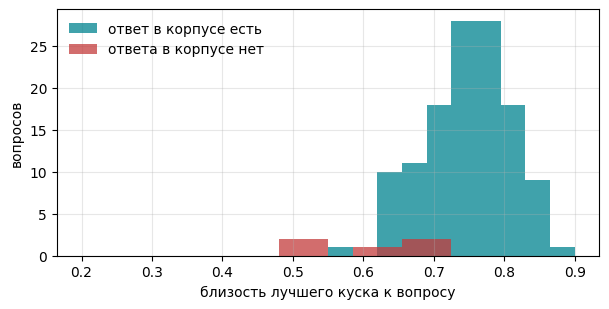

In [41]:
top_answerable = [search_numpy(q, line_vecs, 1)[0][1] for q in q_vecs]
top_unanswerable = [r["hits"][0]["score"] for r in refusals]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(top_answerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["teal"], label="ответ в корпусе есть")
ax.hist(top_unanswerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["red"], label="ответа в корпусе нет")
ax.set_xlabel("близость лучшего куска к вопросу"); ax.set_ylabel("вопросов"); ax.legend(frameon=False); ax.grid(alpha=0.3)
round(float(np.median(top_answerable)), 3), round(float(np.median(top_unanswerable)), 3)

## Спринт 7. Память агента

У модели памяти нет: помнит ваш код, который кладёт нужное в контекст. Сегодня собираем обе памяти из четвёртой лекции. Эпизодическая: журнал всех реплик в файле, в контекст он не идёт. Семантическая: короткие факты о пользователе, которые дешёвая модель извлекает из диалога отдельным вызовом. Она возвращает обновлённый список целиком, поэтому «переехал», «передумал», «больше не интересуюсь» заменяют старый факт, а не ложатся рядом с ним.

Факты лежат там же, где знания: в Milvus, отдельной коллекцией. К вопросу достаём не все факты, а три ближайших. В контекст идут системный промпт, эти факты, найденные куски корпуса и окно последних реплик. Вся остальная история остаётся в журнале.

Память помогает и поиску. «Что нового в моих темах?» без фактов не ищется никак, а факты, приклеенные к каждому запросу, портят конкретные вопросы: к вопросу про футбол подмешивается хоккей. Поэтому ищем дважды, по самому вопросу и по вопросу с фактами, и сливаем два списка уже знакомым `rrf`. Искать имеет смысл только на вопросы: на «привет, я Лена» база вернёт пять случайных строк, и модель послушно начнёт их пересказывать. Пока это грубая проверка на вопросительный знак, в восьмом спринте решать будет сама модель.

Две дырки: извлечение фактов и поиск по ним. Чекпоинт: во второй сессии агент знает, кто вы и что вам интересно, устаревший факт заменён, а на графике видно, сколько токенов экономит окно с фактами против «тащим всю историю».

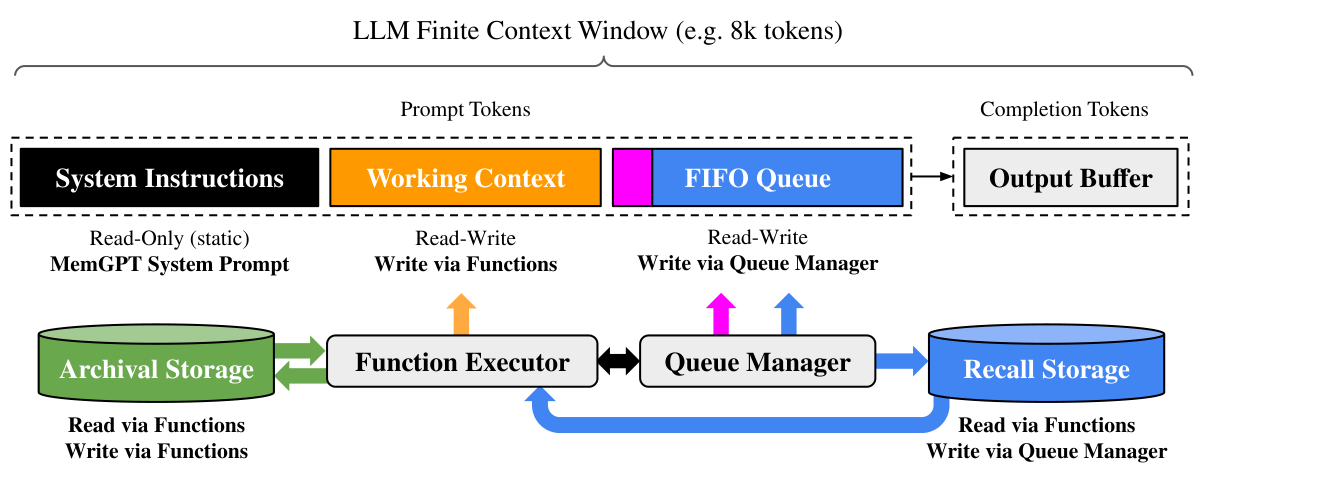

*Packer et al., 2023. MemGPT: контекст как оперативная память, внешние хранилища как диск. В окне живут инструкции, рабочие факты и очередь последних реплик*

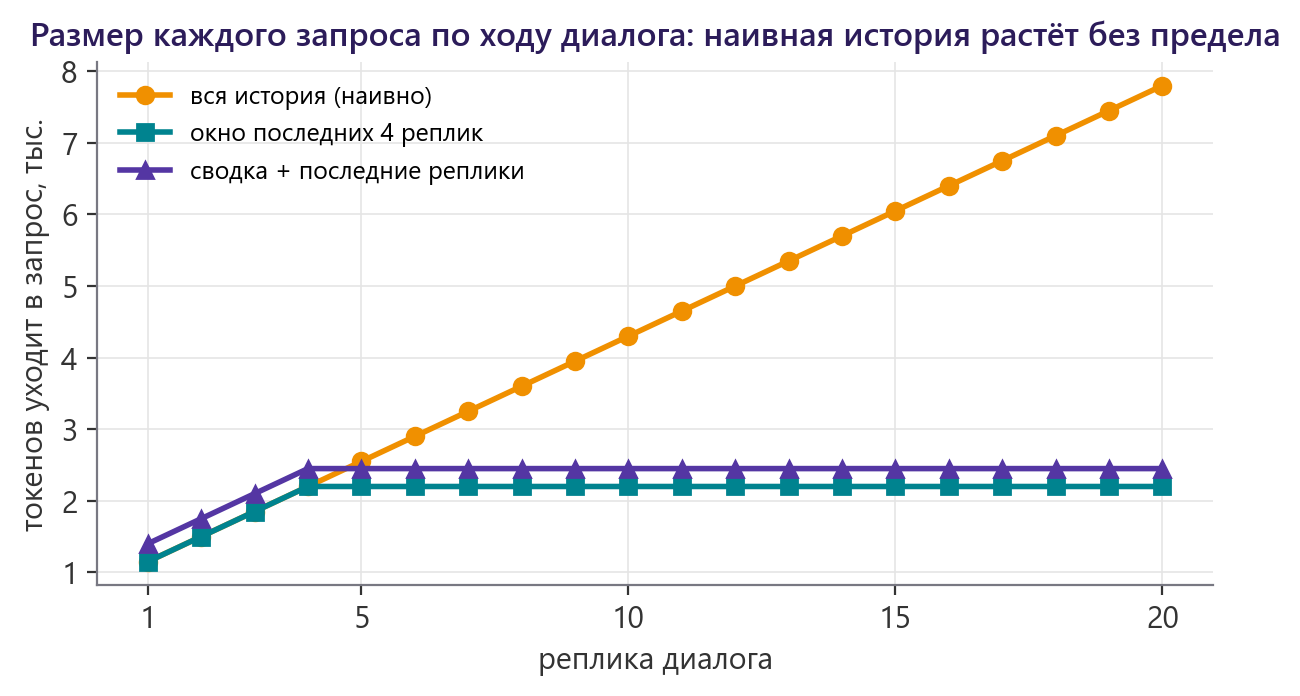

*Из четвёртой лекции: наивная память растёт с каждой репликой, окно и сводка держат запрос плоским*

In [42]:
FACTS_SYSTEM = ("Ты ведёшь память ассистента о пользователе. Верни один JSON-объект вида {\"facts\": [\"...\"]}: полный обновлённый список "
                "коротких фактов о пользователе. Добавь новые устойчивые факты: имя, город, работа, интересы, пожелания к ответам. "
                "Если новый факт отменяет старый, замени старый. Разовые вопросы и мелочи не записывай.")
ASSISTANT_SYSTEM = ("Ты помощник, который отвечает на вопросы о событиях 2026 года по базе знаний. Отвечай на языке пользователя, "
                    "опирайся на источники и на то, что знаешь о пользователе. Источники подобраны автоматически и могут быть не по теме: "
                    "используй только те, что относятся к вопросу. Если в источниках ответа нет, так и скажи.")
JOURNAL, FACTS_FILE = Path("episodes.jsonl"), Path("facts.json")

class Facts(BaseModel):
    facts: list[str] = Field(description="короткие факты о пользователе")

def json_from(text):
    m = re.search(r"\{.*\}", text or "", re.S)
    cleaned = re.sub(r'(\\["\\/bfnrtu])|\\', lambda e: e.group(1) or "\\\\", m.group(0) if m else "{}")
    return json.loads(cleaned, strict=False)

def known_facts():
    return json.loads(FACTS_FILE.read_text(encoding="utf-8")) if FACTS_FILE.exists() else []

def store_facts(facts):
    FACTS_FILE.write_text(json.dumps(facts, ensure_ascii=False, indent=1), encoding="utf-8")
    if facts:
        index_to_milvus("facts", [{"page": "memory", "section": "", "url": "", "text": f} for f in facts], embed_cached(facts))

def remember_episode(session, role, text):
    with JOURNAL.open("a", encoding="utf-8") as f:
        f.write(json.dumps({"session": session, "time": time.strftime("%Y-%m-%d %H:%M:%S"), "role": role, "text": text}, ensure_ascii=False) + "\n")

for path in (JOURNAL, FACTS_FILE):
    path.unlink(missing_ok=True)
if client.has_collection("facts"):
    client.drop_collection("facts")

In [43]:
def recall_facts(question, k=3):
    if not client.has_collection("facts"):
        return []
    return [h["text"] for h in search_milvus("facts", question, k)]

In [44]:
def extract_facts(dialog, known):
    user = f"Известные факты: {json.dumps(known, ensure_ascii=False)}\n\nДиалог:\n{dialog}"
    msg = chat([{"role": "system", "content": FACTS_SYSTEM}, {"role": "user", "content": user}], MODELS["cheap"], tag="facts")
    return Facts(**json_from(msg.get("content") or "")).facts

In [45]:
def search_with_memory(user_text, facts, k=5):
    plain = search_milvus("lines", user_text, k)
    personal = search_milvus("lines", user_text + " " + " ".join(facts), k) if facts else []
    by_id = {h["id"]: h for h in plain + personal}
    return [by_id[i] for i in rrf([[h["id"] for h in plain], [h["id"] for h in personal]], k)]

def talk(session, history, user_text, mode="память"):
    remember_episode(session, "user", user_text)
    facts = recall_facts(user_text) if mode == "память" else []
    hits = search_with_memory(user_text, facts) if "?" in user_text else []
    sources = "\n".join(f"[{i + 1}] ({h['page']}) {h['text']}" for i, h in enumerate(hits)) or "нет"
    system = ASSISTANT_SYSTEM + ("\nЧто известно о пользователе: " + "; ".join(facts) if facts else "")
    window = history[-4:] if mode == "память" else history
    msg = chat([{"role": "system", "content": system}] + window + [{"role": "user", "content": f"Источники:\n{sources}\n\n{user_text}"}],
               MODELS["cheap"], tag=f"dialog: {mode}")
    answer = msg.get("content") or ""
    history += [{"role": "user", "content": user_text if mode == "память" else f"Источники:\n{sources}\n\n{user_text}"}, {"role": "assistant", "content": answer}]
    remember_episode(session, "assistant", answer)
    return answer

def end_session(history):
    dialog = "\n".join(f"{m['role']}: {m['content'][:400]}" for m in history)
    store_facts(extract_facts(dialog, known_facts()))
    return known_facts()

In [46]:
first = []
print(talk("s1", first, "Привет! Я Лена, продуктовый аналитик из Новосибирска. Слежу за космосом и хоккеем, отвечай коротко."))
print(talk("s1", first, "Что было в космосе в июле 2026 года?"))
end_session(first)

Привет, Лена! Какой у тебя вопрос о событиях 2026 года?
В июле 2026 года в космосе запланированы несколько значимых событий, включая продолжение миссий на Международной космической станции и возможные запуски новых спутников. Однако конкретные детали о событиях в этом месяце в доступных источниках отсутствуют. Если есть что-то конкретное, что тебя интересует, дай знать!


['Имя: Лена',
 'Город: Новосибирск',
 'Работа: продуктовый аналитик',
 'Интересы: космос, хоккей',
 'Пожелания к ответам: отвечай коротко']

In [47]:
second = []
print(talk("s2", second, "Что интересного случилось в моих темах за лето?"))
print(talk("s2", second, "Хоккей я забросила, теперь слежу за футболом. И я переехала в Калининград."))
print(talk("s2", second, "Кто выиграл чемпионат мира по футболу?"))
end_session(second)

Летом 2026 года в области космоса произошло восстановление связи с экспериментальной миссией ESA PROBA-3, которая потеряла контакт в феврале, но возобновила наблюдения в июле. К сожалению, информации о хоккее за это время нет.
Спасибо за обновление! Летом 2026 года в мире футбола произошло несколько интересных событий. Например, в июне завершился чемпионат мира по футболу, который проходил в Катаре. В финале встретились сборные Бразилии и Франции, и бразильцы одержали победу, завоевав свой шестой титул чемпиона мира. 

Если у тебя есть конкретные вопросы о футболе или событиях в Калининграде, дай знать!
Чемпионат мира по футболу 2026 года выиграла сборная Бразилии, которая одержала победу в финале над Францией.


['Имя: Лена',
 'Город: Калининград',
 'Работа: продуктовый аналитик',
 'Интересы: космос, футбол',
 'Пожелания к ответам: отвечай коротко']

,prompt,cost
tag,,
dialog: память,4677,0.00093
dialog: вся история,15872,0.00209


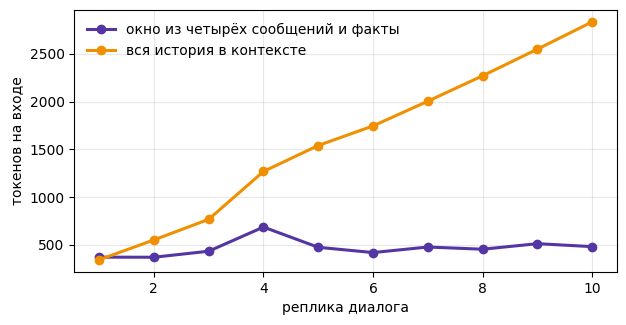

In [48]:
SCRIPT = [t["question"] for t in tasks[40:50]]
for mode in ("память", "вся история"):
    history = []
    for q in SCRIPT:
        talk("bench", history, q, mode)
per_turn = pd.DataFrame([c for c in ledger.calls if c["tag"].startswith("dialog: ")][-2 * len(SCRIPT):])
fig, ax = plt.subplots(figsize=(7, 3.4))
for (tag, part), color in zip(per_turn.groupby("tag", sort=False), [COLORS["violet"], COLORS["amber"]]):
    ax.plot(range(1, len(part) + 1), part["prompt"].values, marker="o", lw=2.2, color=color,
            label={"dialog: память": "окно из четырёх сообщений и факты", "dialog: вся история": "вся история в контексте"}[tag])
ax.set_xlabel("реплика диалога"); ax.set_ylabel("токенов на входе"); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/memory_tokens.png", dpi=150, bbox_inches="tight")
per_turn.groupby("tag", sort=False).agg(prompt=("prompt", "sum"), cost=("cost", "sum")).round(5)

## Спринт 8. Поиск как инструмент агента

До сих пор поиск делался всегда: пришёл вопрос, нашли куски, ответили. В агенте поиск это инструмент, который модель зовёт сама, когда решит, что ей не хватает знаний. Она может искать несколько раз, уточняя запрос, сузить поиск до одной страницы или не искать вовсе.

Цикл агента берём с первого семинара в сжатом виде. Дырка одна: сам инструмент `knowledge_base` с фильтром по странице. Чекпоинт: те же сорок вопросов двумя способами, «RAG всегда» против «агент решает сам», и итоговая картинка недели. Пунктир на ней это прошлая неделя: поле `agent_ok` в вопросах хранит, ответил ли на вопрос агент с живым поиском по Википедии из первой домашки.

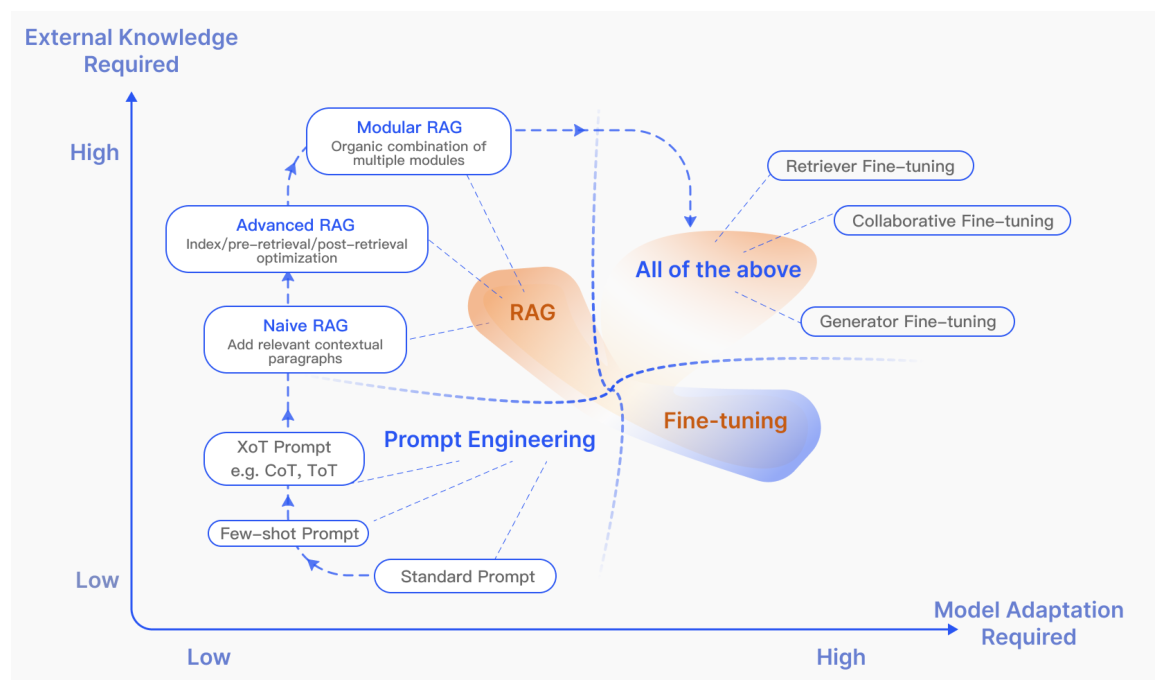

*Gao et al., 2023. Карта приёмов: по вертикали внешние знания, по горизонтали переделка модели. Поиск как инструмент агента это Modular RAG: самый верх карты, а модель мы при этом не трогаем*

In [49]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

def run_tool(call):
    name = call["function"]["name"]
    try:
        spec = TOOLS[name]
        result = spec["fn"](**spec["args"].model_validate_json(call["function"]["arguments"]).model_dump())
    except Exception as e:
        result = f"ошибка инструмента {name}: {e}"
    return {"role": "tool", "tool_call_id": call["id"], "content": str(result)[:3000]}

AGENT_SYSTEM = ("You answer questions about events of 2026. Never answer from memory: look facts up with the tools, do not repeat the same call. "
                "When done, write the last line as FINAL: <short answer>, or NOT_FOUND if the knowledge base has no answer.")

def agent(question, model, max_steps=6):
    messages, seen, before = [{"role": "system", "content": AGENT_SYSTEM}, {"role": "user", "content": question}], set(), ledger.mine
    schemas = [t["schema"] for t in TOOLS.values()]
    for step in range(max_steps):
        msg = chat(messages, model, tools=schemas, tag="agent")
        messages.append(msg)
        calls = msg.get("tool_calls") or []
        keys = {(c["function"]["name"], c["function"]["arguments"]) for c in calls}
        if not calls or keys & seen or step == max_steps - 1:
            break
        seen |= keys
        messages += [run_tool(c) for c in calls]
    if calls:
        messages += [{"role": "tool", "tool_call_id": c["id"], "content": "call rejected: answer from what you already have"} for c in calls]
        msg = chat(messages, model, tag="agent")
    searches = sum(m.get("role") == "tool" for m in messages if isinstance(m, dict))
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before, "searches": searches}

class KBArgs(BaseModel):
    query: str = Field(description="short search query in English: names, dates, key terms of the event")
    page: str = Field(default="", description="optional exact page title to search within, for example '2026 in Japan'; empty means all pages")

In [50]:
def knowledge_base(query: str, page: str = "") -> str:
    flt = f'page == "{page}"' if page else ""
    hits = search_milvus("lines", query, 5, flt)
    if not hits:
        return "ничего не найдено"
    return "\n".join(f"({h['page']}, {h['section']}) {h['text']}" for h in hits)


In [51]:
register(knowledge_base, KBArgs, "Searches the local knowledge base of 2026 events and returns the five closest facts with their page and section")
out = agent(tasks[3]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[3]["answer"], "| обращений к базе:", out["searches"], "| цена, центов:", round(out["cost"] * 100, 4))

In March 2026, Ukraine and Romania signed a strategic partnership agreement focusing on the defense and energy sectors. 

FINAL: strategic partnership agreement in defense and energy sectors | эталон: a strategic partnership agreement | обращений к базе: 1 | цена, центов: 0.0102


,config,model,n,accuracy,cost_per_task,cost_per_correct
0,"RAG, k=5",gpt-4o-mini,40,0.65,0.00005,0.00008
1,агент с инструментом,gpt-4o-mini,40,0.85,0.00018,0.00021


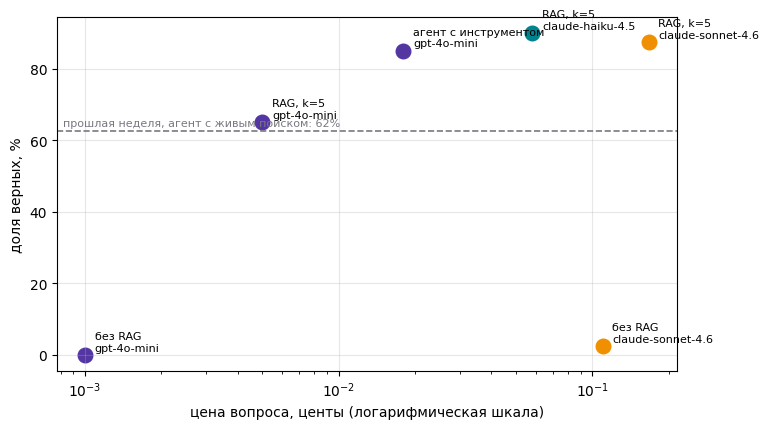

In [52]:
agent_results = evaluate(agent, sample, "агент с инструментом", MODELS["cheap"])
always = results[(results["config"] == "RAG, k=5") & (results["model"] == "gpt-4o-mini")]
final_table = report(pd.concat([results, agent_results], ignore_index=True))
last_week = float(np.mean([t["agent_ok"] for t in sample]))
money_chart(final_table, "img/money_all.png", baseline=(f"прошлая неделя, агент с живым поиском: {last_week:.0%}", last_week))
report(pd.concat([always, agent_results], ignore_index=True))

In [53]:
ledger.table(), round(ledger.total, 3)

(                                            calls  prompt  completion     cost
 tag                 model                                                     
 agent               gpt-4o-mini               104   36624        3173  0.00740
 dialog: вся история gpt-4o-mini                10   15872         437  0.00209
 dialog: память      gpt-4o-mini                15    5999         671  0.00130
 embed               text-embedding-3-small      7      72           0  0.00000
 facts               gpt-4o-mini                 2     678         105  0.00016
 plain               claude-sonnet-4.6          40    2296        2474  0.04400
                     gpt-4o-mini                40    2254         368  0.00056
 rag                 claude-haiku-4.5           40   10344        2607  0.02338
                     claude-sonnet-4.6          40   10384        2370  0.06670
                     gpt-4o-mini               211   46511        5105  0.01004,
 0.156)

## Дополнение. Тот же конвейер на PDF

Для тех, кто закончил раньше, и для домашки на своём корпусе. PDF это картинка с буквами: текст из него достаётся постранично, колонки и таблицы превращаются в поток строк. Ниже самый простой путь через `pypdf`: страница это кусок, имя файла и номер страницы едут метаданными. Корпусом служат материалы самого курса: пятая и шестая лекции и задание первой недели.

Посмотрите, во что превратилась таблица с критериями оценки: заголовок и строки идут подряд без границ, и нарезка по символам легко оторвёт одно от другого. Для серьёзных документов берут разборщики структуры вроде Docling и Unstructured, о них говорили на шестой лекции.

In [54]:
from pypdf import PdfReader

def pdf_chunks(path):
    reader = PdfReader(str(path))
    pages = [(n + 1, " ".join((p.extract_text() or "").split())) for n, p in enumerate(reader.pages)]
    return [{"page": path.name, "section": f"стр. {n}", "url": "", "text": text} for n, text in pages if len(text) >= 80]

pdf = [c for path in sorted((DATA / "pdf").glob("*.pdf")) for c in pdf_chunks(path)]
index_to_milvus("course", pdf, embed_cached([emb_text(c) for c in pdf]))
save_cache()
len(pdf), pdf[0]["text"][:200]

(37,
 '1 Избранные задачи части B профильного ЕГЭ по математике из открытого банка Задание номер 1. 6195. В городе N живет 200000 жителей. Среди них 15 % детей и подростков. Среди взрослых 35% не работает (п')

In [57]:
COURSE_SYSTEM = RAG_SYSTEM.replace("Answer the question", "Answer in Russian")
for q in [
    "В доме один подъезд, на каждом этаже по шесть квартир. Наташа живёт в квартире номер 52. На каком этаже её квартира?",
    "Комиссия платежного терминала 3%, принимает суммы кратные 10 рублям. Сколько минимум нужно внести, чтобы после комиссии на счету осталось не меньше 550 рублей?",
    "На теннисном турнире 46 участников, среди них 19 из России, включая Ярослава Исакова. Пары в первом туре формируются случайным жребием. Какова вероятность, что Ярослав Исаков попадёт в пару с кем-то из России?",
]:
    hits = search_milvus("course", q, 3)
    sources = "\n".join(f"[{i + 1}] ({h['page']}, {h['section']}) {h['text'][:3000]}" for i, h in enumerate(hits))
    msg = chat([{"role": "system", "content": COURSE_SYSTEM}, {"role": "user", "content": f"Sources:\n{sources}\n\nQuestion: {q}"}], MODELS["cheap"], tag="pdf")
    print(q, "\n ", " ".join((msg.get("content") or "").split())[:600], "\n  источники:", [(h["page"], h["section"]) for h in hits], "\n")

В доме один подъезд, на каждом этаже по шесть квартир. Наташа живёт в квартире номер 52. На каком этаже её квартира? 
  Наташа живёт в квартире номер 52. В доме один подъезд, на каждом этаже по шесть квартир. Чтобы определить, на каком этаже находится квартира 52, нужно разделить номер квартиры на количество квартир на этаже и округлить вверх. 52 / 6 = 8,67, округляем до 9. Ответ: Наташа живёт на 9 этаже [1]. FINAL: 9. 
  источники: [('ege_math_partB.PDF', 'стр. 1'), ('ege_math_partB.PDF', 'стр. 2'), ('ege_math_partB.PDF', 'стр. 25')] 

Комиссия платежного терминала 3%, принимает суммы кратные 10 рублям. Сколько минимум нужно внести, чтобы после комиссии на счету осталось не меньше 550 рублей? 
  Чтобы на счету фирмы, предоставляющей интернет-услуги, оказалась сумма не менее 550 рублей, необходимо учесть комиссию терминала в 3%. Обозначим сумму, которую нужно внести, как X. После вычета комиссии на счету останется 97% от X, то есть: 0,97X ≥ 550. Решим это неравенство: X ≥ 550 / 0,97 ≈ 

## Домашка

Полное задание в `homework02.pdf`, срок воскресенье 27.09, 23:59. Коротко: перенести этот конвейер на свой корпус, собрать для него двадцать-тридцать вопросов с эталонными кусками, замерить recall@k и цену верного ответа, дать агенту долгую память и показать вторую сессию, в которой он помнит пользователя.